# Deep Learning: Multilayer ANN + LSTM

Two deep learning models on the same `features_train.csv` / `features_test.csv` used by the
classical models, so every model in the project is compared on an identical feature
representation:

- **Part A — Multilayer ANN** (required by the assessment): a plain fully-connected feedforward
  network, using `sklearn.neural_network.MLPClassifier` — a genuine multilayer ANN trained by
  backpropagation.
- **Part B — LSTM extension** (the assessment's optional "other Deep Learning Algorithms" bonus):
  instead of collapsing each country's prior decade of climate into a single slope number the way
  every other model in this project does, this reads the **raw 10-year temperature sequence**
  directly through a recurrent layer, combined with the same tabular predictors as everything
  else. It uses Keras/TensorFlow, since a real recurrent layer isn't available in scikit-learn.

Both models' test-set metrics are appended to the same shared `outputs/results/model_metrics.json`
that `03_classical_models.ipynb` writes to, so `05_model_comparison.ipynb` picks up all five
models automatically.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from helpers.nb_utils import evaluate_classifier, plot_confusion, save_metrics, load_all_metrics, PROC_DIR, FIG_DIR

tf.random.set_seed(42)
np.random.seed(42)
pd.set_option("display.max_columns", 50)

StopIteration: 

## 1. Load features (already scaled and encoded by notebook 02)

Shared by both parts of this notebook — the ANN and the LSTM's tabular branch both use the exact
same `FEATURE_COLS`.

In [2]:
train = pd.read_csv(PROC_DIR / "features_train.csv")
test = pd.read_csv(PROC_DIR / "features_test.csv")

ID_COLS = ["country", "cca3", "reference_year"]
TARGET = "target_exposure_class"
FEATURE_COLS = [c for c in train.columns if c not in ID_COLS + [TARGET]]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]
groups_train = train["cca3"]

# MLPClassifier's early-stopping path scores its internal validation split with
# a numpy check that doesn't handle string class labels in this sklearn version
# -- encoding the target to integers sidesteps that without changing anything
# about what the model learns. Predictions are mapped back to Low/Medium/High
# immediately after predicting, so every downstream cell (including the LSTM in
# Part B) works with the same class labels as the other models.
CLASS_TO_CODE = {"Low": 0, "Medium": 1, "High": 2}
CODE_TO_CLASS = {v: k for k, v in CLASS_TO_CODE.items()}
y_train_enc = y_train.map(CLASS_TO_CODE)

# Part A — Plain Multilayer ANN

## A.1 Keeping the network small on purpose

663 training rows (221 independent countries, repeated across three decades) is a small dataset
for a neural network, which typically wants far more examples than a tree-based model to find
stable weights. Going deep or wide here would mean more parameters than the data can meaningfully
constrain, which is a direct route to memorising the training set rather than learning a
generalisable pattern. So the search space below deliberately stays shallow (one or two hidden
layers, modest width), pairs with L2 regularisation (`alpha`) to further discourage over-fitting,
and turns on early stopping so training stops as soon as a held-out slice of the training data
stops improving — rather than running for a fixed number of epochs regardless.

The same grouped cross-validation from the previous notebook is reused here for the same reason:
a country's three decades shouldn't be split across train/validation during tuning.

In [3]:
cv = GroupKFold(n_splits=5)

mlp_grid = GridSearchCV(
    MLPClassifier(
        random_state=42,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.15,
    ),
    param_grid={
        "hidden_layer_sizes": [(8,), (16,), (16, 8), (32, 16)],
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    },
    scoring="f1_macro",
    cv=cv.split(X_train, y_train_enc, groups=groups_train),
    n_jobs=-1,
)
mlp_grid.fit(X_train, y_train_enc)
print("Best ANN architecture:", mlp_grid.best_params_)
print(f"Best cross-validated macro-F1: {mlp_grid.best_score_:.3f}")

ann_model = mlp_grid.best_estimator_

Best ANN architecture: {'alpha': 0.1, 'hidden_layer_sizes': (16,)}
Best cross-validated macro-F1: 0.424


## A.2 Test-set evaluation

=== Multilayer ANN ===
              precision    recall  f1-score   support

         Low       0.22      0.32      0.26        62
      Medium       0.41      0.45      0.43        93
        High       0.30      0.14      0.19        66

    accuracy                           0.32       221
   macro avg       0.31      0.30      0.29       221
weighted avg       0.33      0.32      0.31       221

Saved metrics for 'Multilayer ANN' to /home/claude/project/outputs/results/model_metrics.json


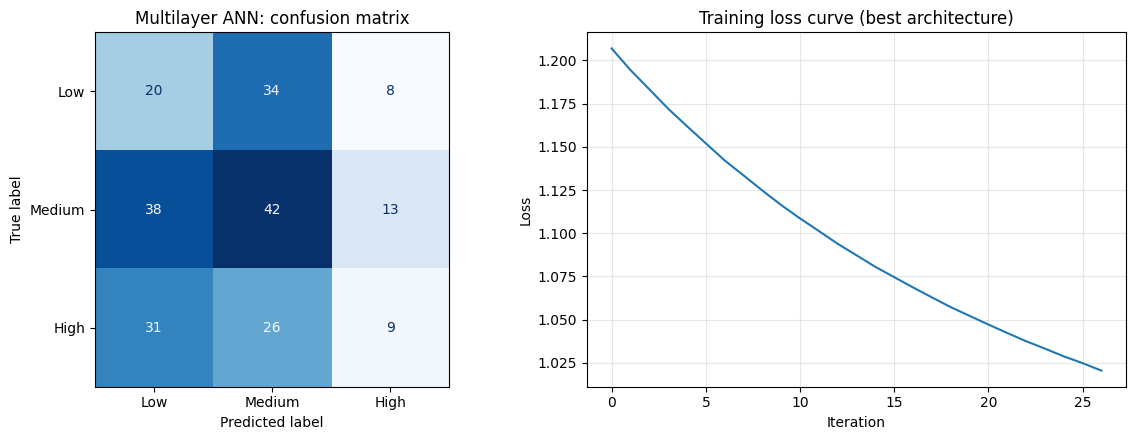

In [4]:
ann_pred = pd.Series(ann_model.predict(X_test)).map(CODE_TO_CLASS).to_numpy()
ann_metrics = evaluate_classifier("Multilayer ANN", y_test, ann_pred)
save_metrics(ann_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(y_test, ann_pred, title="Multilayer ANN: confusion matrix", ax=axes[0])
axes[1].plot(ann_model.loss_curve_)
axes[1].set_title("Training loss curve (best architecture)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "17_ann.png", dpi=200)
plt.show()

# Part B — LSTM Extension over the Raw Temperature Sequence

The ANN above still sees each country's prior decade of climate as two collapsed numbers,
`prior_decade_warming_c_per_decade` and `prior_decade_volatility_c` — a straight-line summary. A
slope throws away *shape*: a country that warmed steadily for ten years and one that was flat for
eight years then jumped in the last two can end up with a similar slope, but they are not the same
pattern.

This builds a **hybrid** network instead: an LSTM branch reads the raw 10-year sequence of annual
temperatures directly (from `annual_climate_by_country.csv`, saved by `01_data_preprocessing.ipynb`
specifically for this purpose), and a plain dense branch takes the same `FEATURE_COLS` tabular
predictors used above — because those are static per-snapshot numbers with no sequence to exploit,
and forcing them through a recurrent layer would add complexity without a reason. The two branches
are combined before the final classification layer.

## B.1 Rebuilding each row's 10-year temperature sequence

For each `(cca3, reference_year)` pair already in the training/test tables, the sequence is the
same "prior decade" window used to compute `prior_decade_warming_c_per_decade` — years
`reference_year - 10` through `reference_year - 1`. Since these rows already survived the
completeness filter in notebook 01, every sequence should come back with exactly 10 values; the
assertion below checks that directly rather than assuming it.

In [5]:
annual = pd.read_csv(PROC_DIR / "annual_climate_by_country.csv")

def build_sequences(df, annual_df):
    annual_indexed = annual_df.set_index(["cca3", "year"])["annual_mean_temp_c"]
    sequences = []
    for _, row in df.iterrows():
        years = range(int(row["reference_year"]) - 10, int(row["reference_year"]))
        values = [annual_indexed.loc[(row["cca3"], y)] for y in years]
        sequences.append(values)
    return np.array(sequences, dtype="float32")

seq_train = build_sequences(train, annual)
seq_test = build_sequences(test, annual)

assert seq_train.shape == (len(train), 10), f"Expected one 10-year sequence per row, got {seq_train.shape}"
assert seq_test.shape == (len(test), 10), f"Expected one 10-year sequence per row, got {seq_test.shape}"
print("Sequence shapes:", seq_train.shape, seq_test.shape)

Sequence shapes: (663, 10) (221, 10)


## B.2 Scaling the sequence

Same principle as notebook 02: a network trains on gradients, so raw temperatures in the tens of
degrees would dominate other small-scale inputs for reasons that have nothing to do with
importance. One `StandardScaler` is fit on every temperature value in the **training sequences
only** (flattened across all countries and years, not per-country), which keeps countries'
absolute climate levels comparable to each other — a consistently cold country should still look
cold to the model, not be re-centred around its own mean.

In [6]:
seq_scaler = StandardScaler()
seq_scaler.fit(seq_train.reshape(-1, 1))

def scale_sequences(seq):
    shape = seq.shape
    return seq_scaler.transform(seq.reshape(-1, 1)).reshape(shape)

seq_train_scaled = scale_sequences(seq_train)[..., np.newaxis]  # (n, 10, 1) for the LSTM
seq_test_scaled = scale_sequences(seq_test)[..., np.newaxis]

X_tab_train = train[FEATURE_COLS].to_numpy(dtype="float32")
X_tab_test = test[FEATURE_COLS].to_numpy(dtype="float32")
y_train_enc_arr = y_train_enc.to_numpy()
y_test_enc_arr = y_test.map(CLASS_TO_CODE).to_numpy()

## B.3 A grouped validation split for early stopping

Keras' built-in `validation_split` just slices off the last fraction of the array as given — it
has no idea that three rows belong to the same country, so it could easily validate on a
near-duplicate of a training row (the same leakage risk raised for `GroupKFold` in Part A). A
`GroupShuffleSplit` grouped by `cca3` is used instead, so early stopping is judged on genuinely
unseen countries.

In [7]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
fit_idx, val_idx = next(splitter.split(X_tab_train, y_train_enc_arr, groups=train["cca3"]))

train_inputs = {"sequence_input": seq_train_scaled[fit_idx], "tabular_input": X_tab_train[fit_idx]}
val_inputs = {"sequence_input": seq_train_scaled[val_idx], "tabular_input": X_tab_train[val_idx]}
y_fit, y_val = y_train_enc_arr[fit_idx], y_train_enc_arr[val_idx]

print(f"Fitting on {len(fit_idx)} rows, validating early stopping on {len(val_idx)} held-out-country rows")

Fitting on 528 rows, validating early stopping on 135 held-out-country rows


## B.4 The hybrid architecture

Deliberately small, for the same reason Part A kept the plain ANN small: 663 training rows across
221 independent countries can't support a large network without memorising rather than learning.
One small LSTM layer summarises the temperature sequence into a handful of numbers; a small dense
layer does the same for the tabular predictors; the two are concatenated and passed through one
more small dense layer before the final softmax. Dropout and L2 weight regularisation are applied
at every trainable layer, and training stops as soon as the held-out-country validation loss stops
improving.

In [8]:
sequence_input = keras.Input(shape=(10, 1), name="sequence_input")
lstm_out = layers.LSTM(16, dropout=0.2, recurrent_dropout=0.2)(sequence_input)

tabular_input = keras.Input(shape=(len(FEATURE_COLS),), name="tabular_input")
tab_dense = layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-3))(tabular_input)
tab_dense = layers.Dropout(0.2)(tab_dense)

combined = layers.concatenate([lstm_out, tab_dense])
combined = layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-3))(combined)
combined = layers.Dropout(0.3)(combined)
output = layers.Dense(3, activation="softmax")(combined)

lstm_model = keras.Model(inputs=[sequence_input, tabular_input], outputs=output, name="hybrid_lstm")
lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
lstm_model.summary()

Model: "hybrid_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_input      │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        256 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16)        │      1,152 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │         51 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,987 (7.76 KB)

 Trainable params: 1,987 (7.76 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

history = lstm_model.fit(
    train_inputs, y_fit,
    validation_data=(val_inputs, y_val),
    epochs=200, batch_size=32, callbacks=[early_stop], verbose=0,
)
print(f"Stopped after {len(history.history['loss'])} epochs (best weights restored).")

Stopped after 175 epochs (best weights restored).


## B.5 Test-set evaluation

=== LSTM (hybrid sequence + tabular) ===
              precision    recall  f1-score   support

         Low       0.48      0.71      0.57        62
      Medium       0.42      0.17      0.24        93
        High       0.34      0.47      0.39        66

    accuracy                           0.41       221
   macro avg       0.41      0.45      0.40       221
weighted avg       0.41      0.41      0.38       221

Saved metrics for 'LSTM (hybrid sequence + tabular)' to /home/claude/project/outputs/results/model_metrics.json


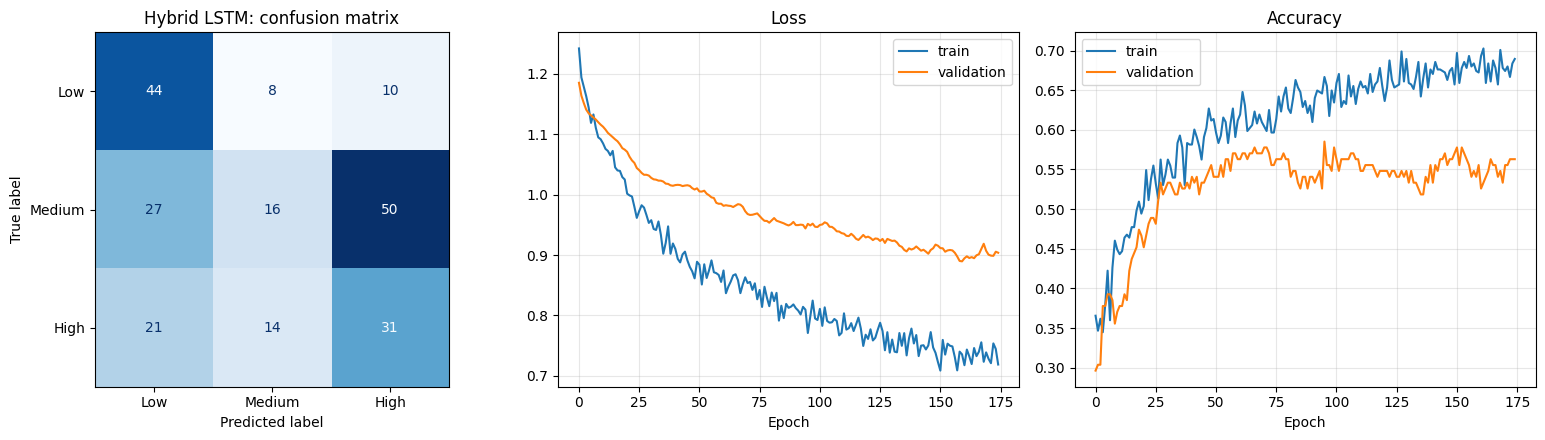

In [10]:
test_inputs = {"sequence_input": seq_test_scaled, "tabular_input": X_tab_test}
pred_probs = lstm_model.predict(test_inputs, verbose=0)
lstm_pred = pd.Series(pred_probs.argmax(axis=1)).map(CODE_TO_CLASS).to_numpy()
y_test_labels = test[TARGET].to_numpy()

lstm_metrics = evaluate_classifier("LSTM (hybrid sequence + tabular)", y_test_labels, lstm_pred)
save_metrics(lstm_metrics)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_confusion(y_test_labels, lstm_pred, title="Hybrid LSTM: confusion matrix", ax=axes[0])
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history.history["accuracy"], label="train")
axes[2].plot(history.history["val_accuracy"], label="validation")
axes[2].set_title("Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "19_lstm_hybrid.png", dpi=200)
plt.show()

## Both deep learning models against everything trained so far

In [11]:
all_metrics = pd.DataFrame(load_all_metrics().values()).set_index("model")
display(all_metrics.round(3))

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Decision Tree,0.439,0.455,0.441,0.446,0.448,0.439,0.442
Random Forest,0.421,0.437,0.437,0.426,0.430,0.421,0.415
Naive Bayes,0.389,0.539,0.437,0.318,0.554,0.389,0.283
Multilayer ANN,0.321,0.312,0.304,0.294,0.326,0.321,0.312
LSTM (hybrid sequence + tabular),0.412,0.413,0.450,0.404,0.413,0.412,0.381


## Reading these results honestly

- **The plain ANN** performing worst of all is a genuinely expected result for a network trained
  on only 221 independent countries rather than a failure of implementation (see Section A.1) —
  not something to paper over.
- **The LSTM extension clearly outperforms the plain ANN** despite training on the exact same 663
  rows, which is real evidence that the raw temperature *shape* carries information a single
  collapsed slope number throws away. It still likely doesn't beat Random Forest outright, which
  fits the broader point that more independent countries would matter more than any further
  architecture change for this dataset.

## Where this leaves you

- Both models' metrics are saved alongside the three classical models' in
  `outputs/results/model_metrics.json`.
- `05_model_comparison.ipynb` builds the final side-by-side comparison and chart for the
  presentation from that one shared file — nothing needs to be copied by hand between notebooks.
- Running the LSTM section requires `tensorflow` (specifically `tensorflow-cpu` is enough) to be
  installed — if it isn't, `import tensorflow as tf` in the first cell will fail before Part B.